# SDSS Objects

## Overview

This notebook classifies Sloan Digital Sky Survey (SDSS) photometric objects as **STAR** or **GALAXY** using multi-band magnitude features. The dataset contains 45,000 observations.

**Target:** `object_type` — binary classification (STAR = 0, GALAXY = 1)  
**Features:** Sky coordinates (ra, dec), SDSS ugriz model magnitudes, PSF magnitude, quality flag

---

## Table of Contents

1. [Data Overview](#1-data-overview)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis-eda)
   - 2.1 [Target Distribution](#21-target-distribution)
   - 2.2 [Feature Distributions by Object Type](#22-feature-distributions-by-object-type)
   - 2.3 [Outlier Detection & Removal](#23-outlier-detection--removal)
   - 2.4 [Correlation Analysis](#24-correlation-analysis)
   - 2.5 [Multicollinearity Analysis (VIF)](#25-multicollinearity-analysis-vif)
3. [Data Preparation](#3-data-preparation)
4. [Modelling](#4-modelling)
   - 4.1 [Logistic Regression](#41-logistic-regression)
   - 4.2 [Random Forest](#42-random-forest)
   - 4.3 [Support Vector Classifier (SVC)](#43-support-vector-classifier-svc)
   - 4.4 [K-Nearest Neighbors (KNN)](#44-k-nearest-neighbors-knn)
   - 4.5 [XGBoost](#45-xgboost)
   - 4.6 [CatBoost](#46-catboost)
5. [Model Comparison](#5-model-comparison)
6. [Conclusion](#6-conclusion)

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression, ElasticNet 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

PALETTE = {'STAR': '#1f77b4', 'GALAXY': '#d62728'}

## 1. Data Overview



## Column Descriptions;

- **ra:** Right Ascension of the object (in degrees, J2000)

- **dec:** Declination of the object (in degrees, J2000)

- **object_type:** Morphological classification from SDSS: STAR, GALAXY

- **modelMag_u:** SDSS u-band model magnitude

- **modelMag_g:** SDSS g-band model magnitude

- **modelMag_r:** SDSS r-band model magnitude

- **modelMag_i:** SDSS i-band model magnitude

- **modelMag_z:** SDSS z-band model magnitude

- **psfMag_r:** SDSS r-band PSF magnitude (point-source fit)

### 1.1 Loading the Dataset

In [39]:
df = pd.read_csv("Objects.csv")
print(df.shape)
df.head()

(45000, 12)


,objID,ra,dec,object_type,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,psfMag_r,clean,flags
0,1237655549129261058,238.593805,-1.027099,STAR,18.83619,17.39126,16.84484,16.58721,16.42528,16.84720,0,68988043776
1,1237655549129261061,238.608517,-1.151029,STAR,17.69599,15.95406,15.20453,14.89701,14.71652,15.20235,0,35255507619856
2,1237655549129261062,238.610665,-1.153622,STAR,23.98905,21.79921,20.66975,20.08602,19.87255,20.65793,0,72092847398064400
3,1237655549129261063,238.610172,-1.151936,STAR,24.82423,22.88640,21.99629,20.75805,20.33451,21.99124,0,105622137864464
4,1237655549129261067,238.611385,-0.966862,STAR,18.24983,16.83682,16.27165,16.05263,15.93228,16.27257,0,68988043776


In [40]:
df.isnull().sum()

objID          0
ra             0
dec            0
object_type    0
modelMag_u     0
modelMag_g     0
modelMag_r     0
modelMag_i     0
modelMag_z     0
psfMag_r       0
clean          0
flags          0
dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   objID        45000 non-null  int64  
 1   ra           45000 non-null  float64
 2   dec          45000 non-null  float64
 3   object_type  45000 non-null  object 
 4   modelMag_u   45000 non-null  float64
 5   modelMag_g   45000 non-null  float64
 6   modelMag_r   45000 non-null  float64
 7   modelMag_i   45000 non-null  float64
 8   modelMag_z   45000 non-null  float64
 9   psfMag_r     45000 non-null  float64
 10  clean        45000 non-null  int64  
 11  flags        45000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 4.1+ MB


### 1.2 Data Cleaning

Drop identifier columns (`objID`, `flags`) that carry no predictive signal.

In [42]:
sdss = df.copy()
sdss.drop(columns=['objID', 'flags'], inplace=True)
sdss.head()

,ra,dec,object_type,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,psfMag_r,clean
0,238.593805,-1.027099,STAR,18.83619,17.39126,16.84484,16.58721,16.42528,16.84720,0
1,238.608517,-1.151029,STAR,17.69599,15.95406,15.20453,14.89701,14.71652,15.20235,0
2,238.610665,-1.153622,STAR,23.98905,21.79921,20.66975,20.08602,19.87255,20.65793,0
3,238.610172,-1.151936,STAR,24.82423,22.88640,21.99629,20.75805,20.33451,21.99124,0
4,238.611385,-0.966862,STAR,18.24983,16.83682,16.27165,16.05263,15.93228,16.27257,0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Distribution

C:\Users\user\AppData\Local\Temp\ipykernel_2000\2476601664.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sdss, x='object_type', palette=PALETTE)


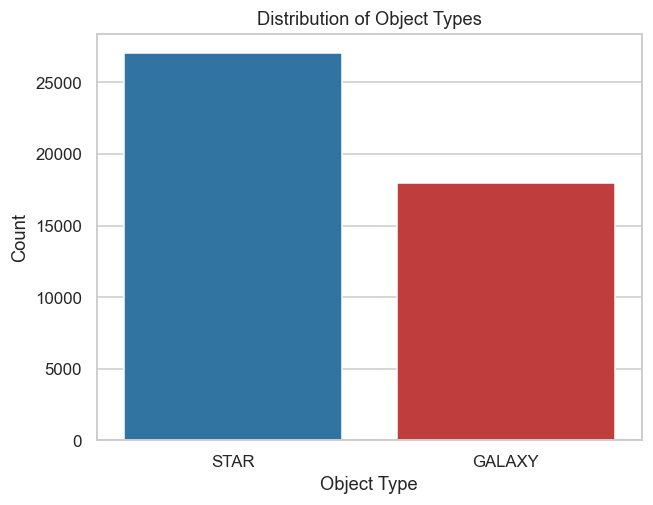

Object Type Counts:
object_type
STAR      27048
GALAXY    17952
Name: count, dtype: int64

Object Type Percentages:
object_type
STAR      60.106667
GALAXY    39.893333
Name: count, dtype: float64


In [43]:
#Target distribution
sns.countplot(data=sdss, x='object_type', palette=PALETTE)
plt.title('Distribution of Object Types')
plt.xlabel('Object Type')
plt.ylabel('Count')
plt.show()

#Object type counts
object_type_counts = sdss["object_type"].value_counts()
#Object type percentage
object_type_percentages = object_type_counts / len(sdss) * 100

print("Object Type Counts:")
print(object_type_counts)
print("\nObject Type Percentages:") 
print(object_type_percentages)

### 2.2 Feature Distributions by Object Type

In [44]:
mag_features = ["modelMag_u", "modelMag_g", "modelMag_r", "modelMag_i", "modelMag_z", "psfMag_r"]

### 2.3 Outlier Detection & Removal

C:\Users\user\AppData\Local\Temp\ipykernel_2000\3242168132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='object_type', y=col, data=sdss, palette=PALETTE)
C:\Users\user\AppData\Local\Temp\ipykernel_2000\3242168132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='object_type', y=col, data=sdss, palette=PALETTE)
C:\Users\user\AppData\Local\Temp\ipykernel_2000\3242168132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='object_type', y=col, data=sdss, palette=PALETTE)
C:\Users\user\AppData\Local\Temp\ipykernel_2000\3242168132

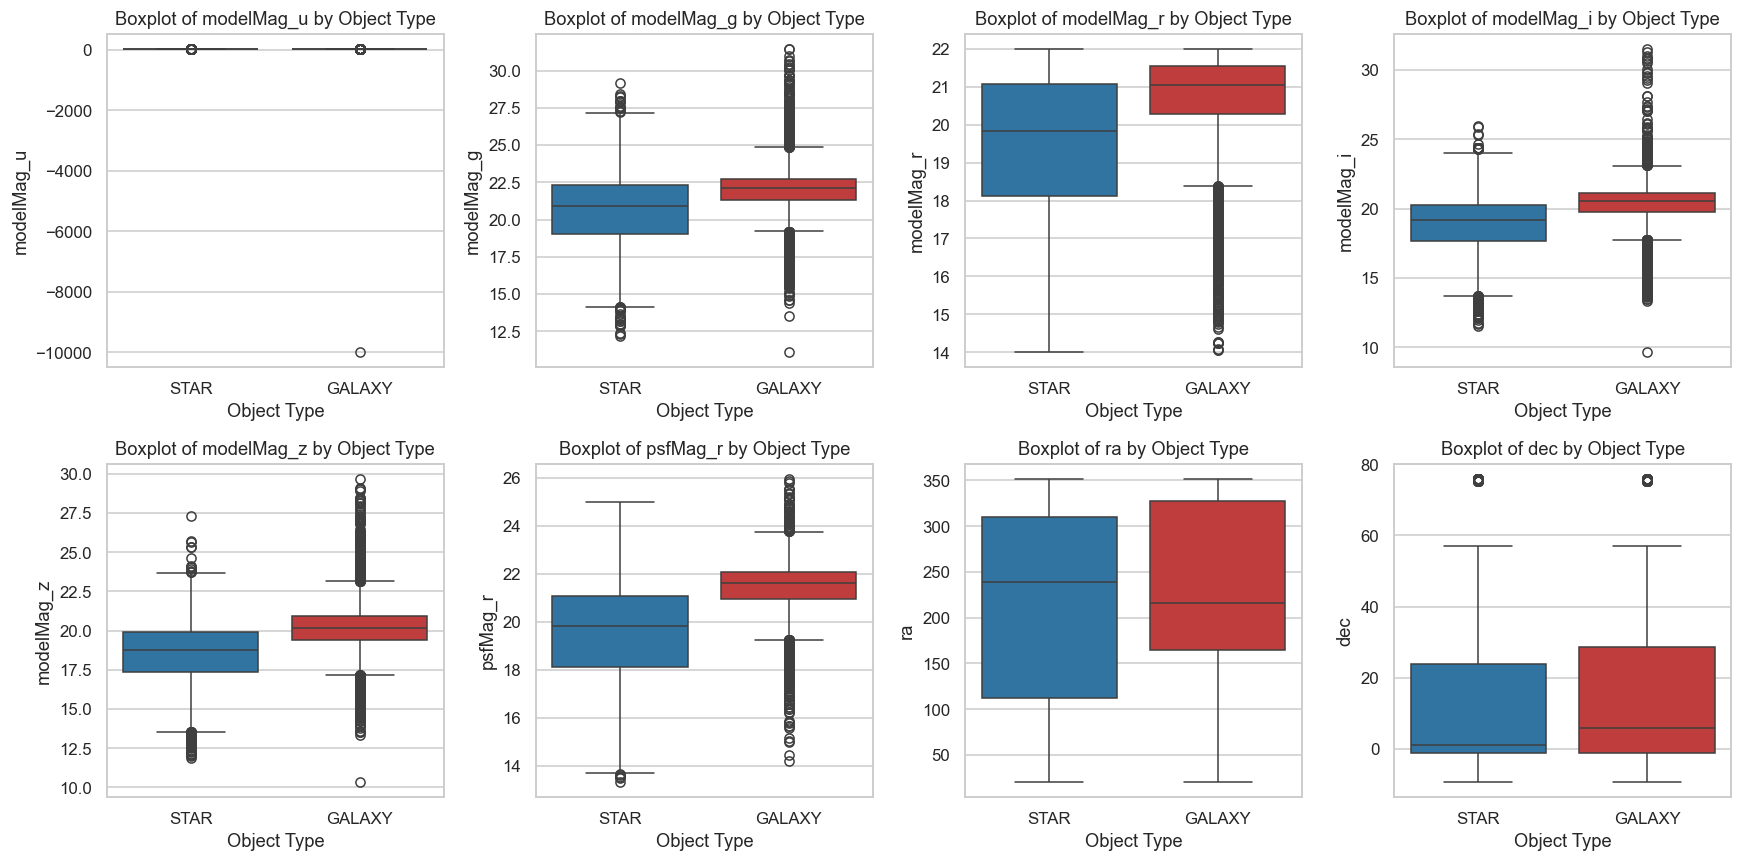

In [ ]:
#Outlier detection using boxplots
plt.figure(figsize=(16, 8))
for i, col in enumerate(mag_features + ["ra", "dec"]):
        plt.subplot(2, 4, i + 1)
        sns.boxplot(x='object_type', y=col, data=sdss, palette=PALETTE)
        plt.title(f'Boxplot of {col} by Object Type')
        plt.xlabel('Object Type')
        plt.ylabel(col)
plt.tight_layout()
plt.show()

In [46]:
#Drop the outlier from modelMag_u / After dropping outlier run the boxplot again for above
sdss = sdss[sdss['modelMag_u'] > 0 ]

C:\Users\user\AppData\Local\Temp\ipykernel_2000\3781964467.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='object_type', y=col, data=sdss, palette=PALETTE)
C:\Users\user\AppData\Local\Temp\ipykernel_2000\3781964467.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='object_type', y=col, data=sdss, palette=PALETTE)
C:\Users\user\AppData\Local\Temp\ipykernel_2000\3781964467.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='object_type', y=col, data=sdss, palette=PALETTE)
C:\Users\user\AppData\Local\Temp\ipykernel_2000\3781964467

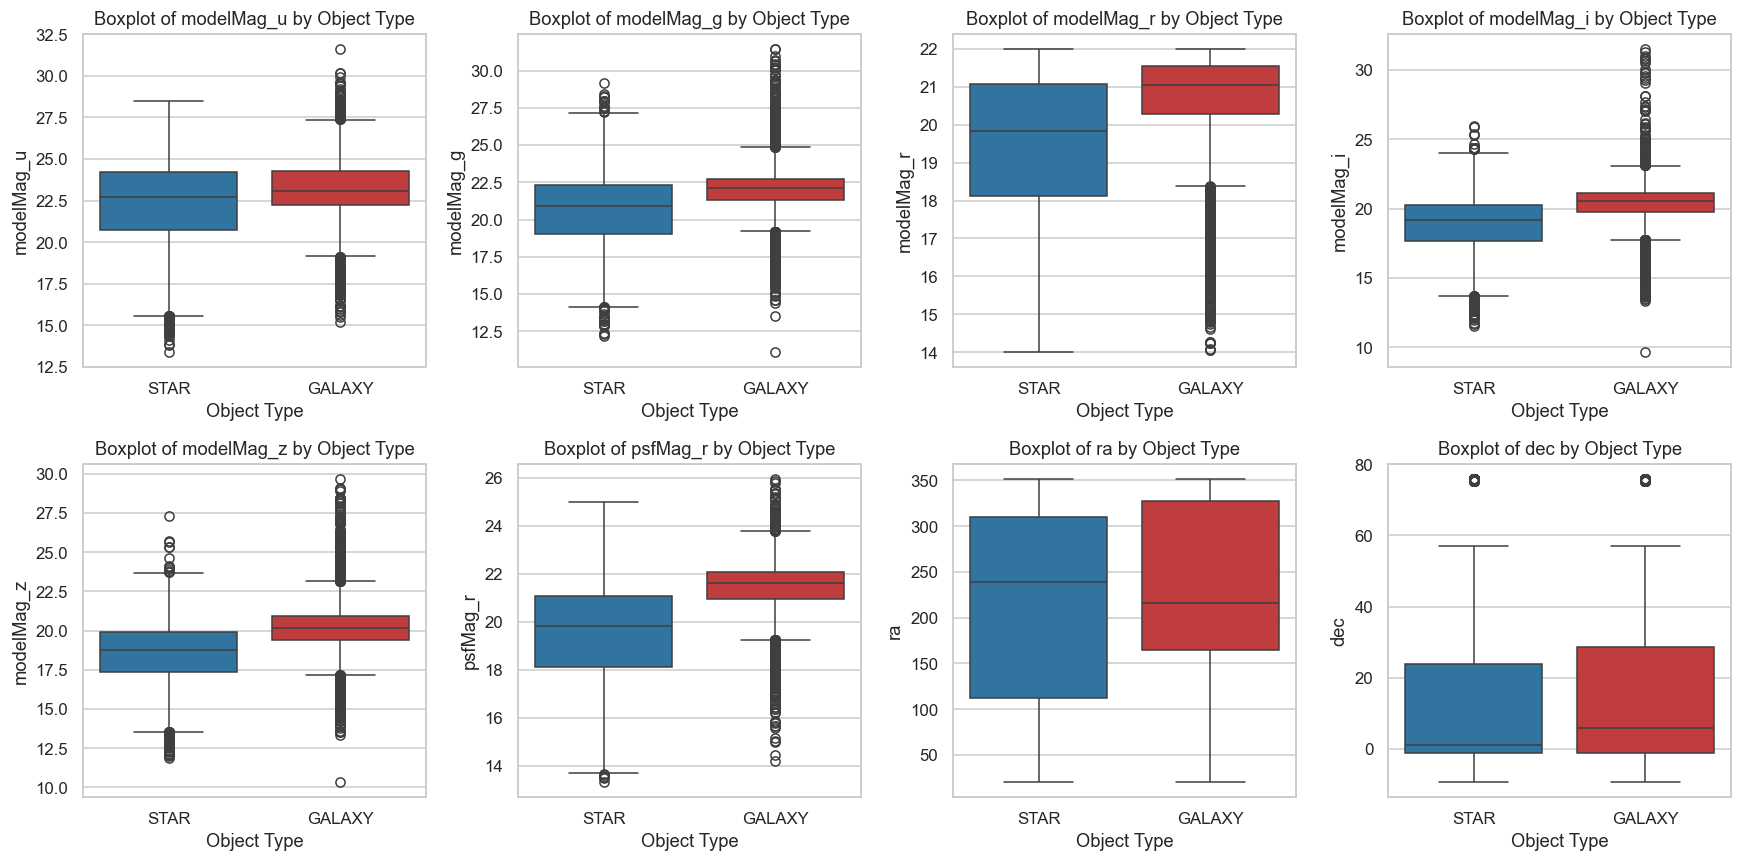

In [47]:
plt.figure(figsize=(16, 8))
for i, col in enumerate(mag_features + ["ra", "dec"]):
        plt.subplot(2, 4, i + 1)
        sns.boxplot(x='object_type', y=col, data=sdss, palette=PALETTE)
        plt.title(f'Boxplot of {col} by Object Type')
        plt.xlabel('Object Type')
        plt.ylabel(col)
plt.tight_layout()
plt.show()

### 2.4 Correlation Analysis

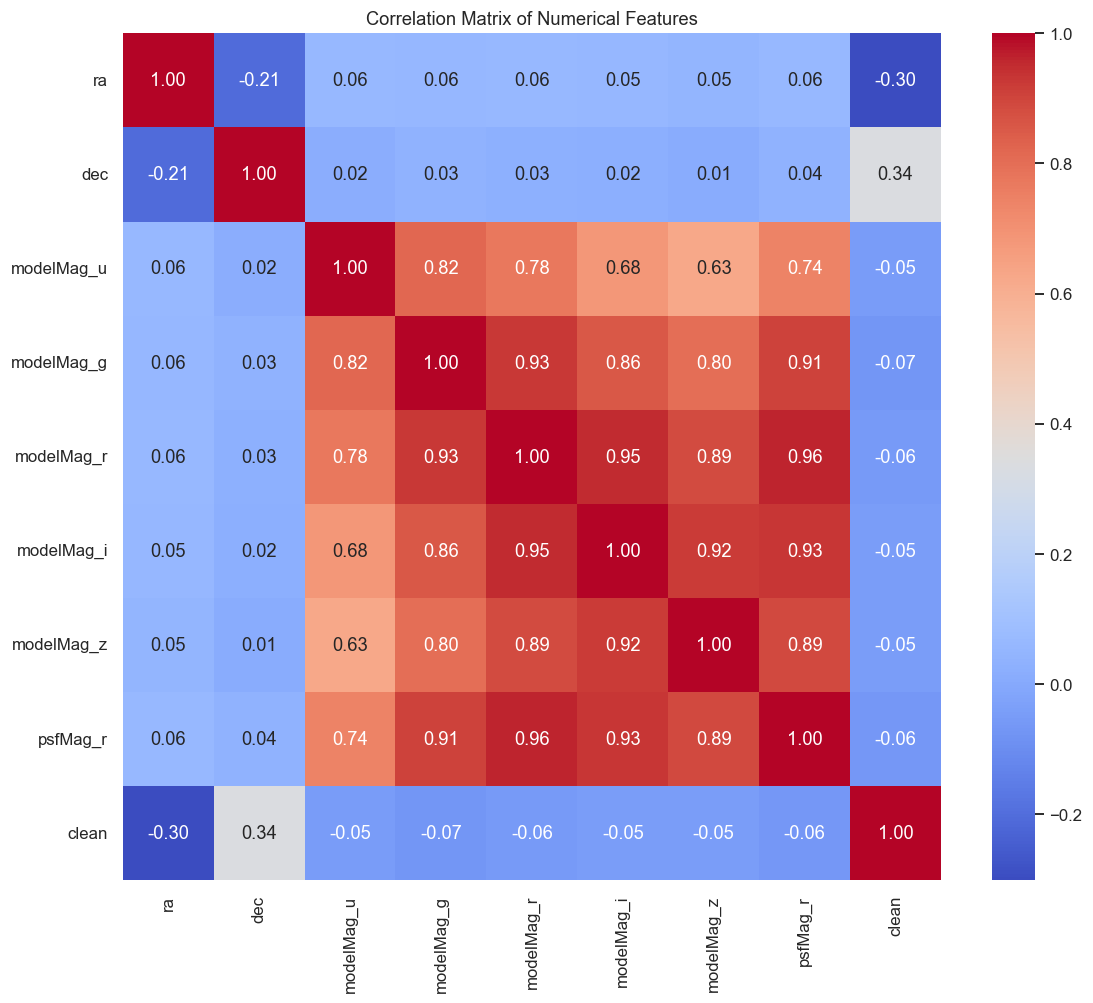

In [48]:
#Correlation matrix
num_cols = sdss.select_dtypes(include=np.number).columns
corr_matrix = sdss[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

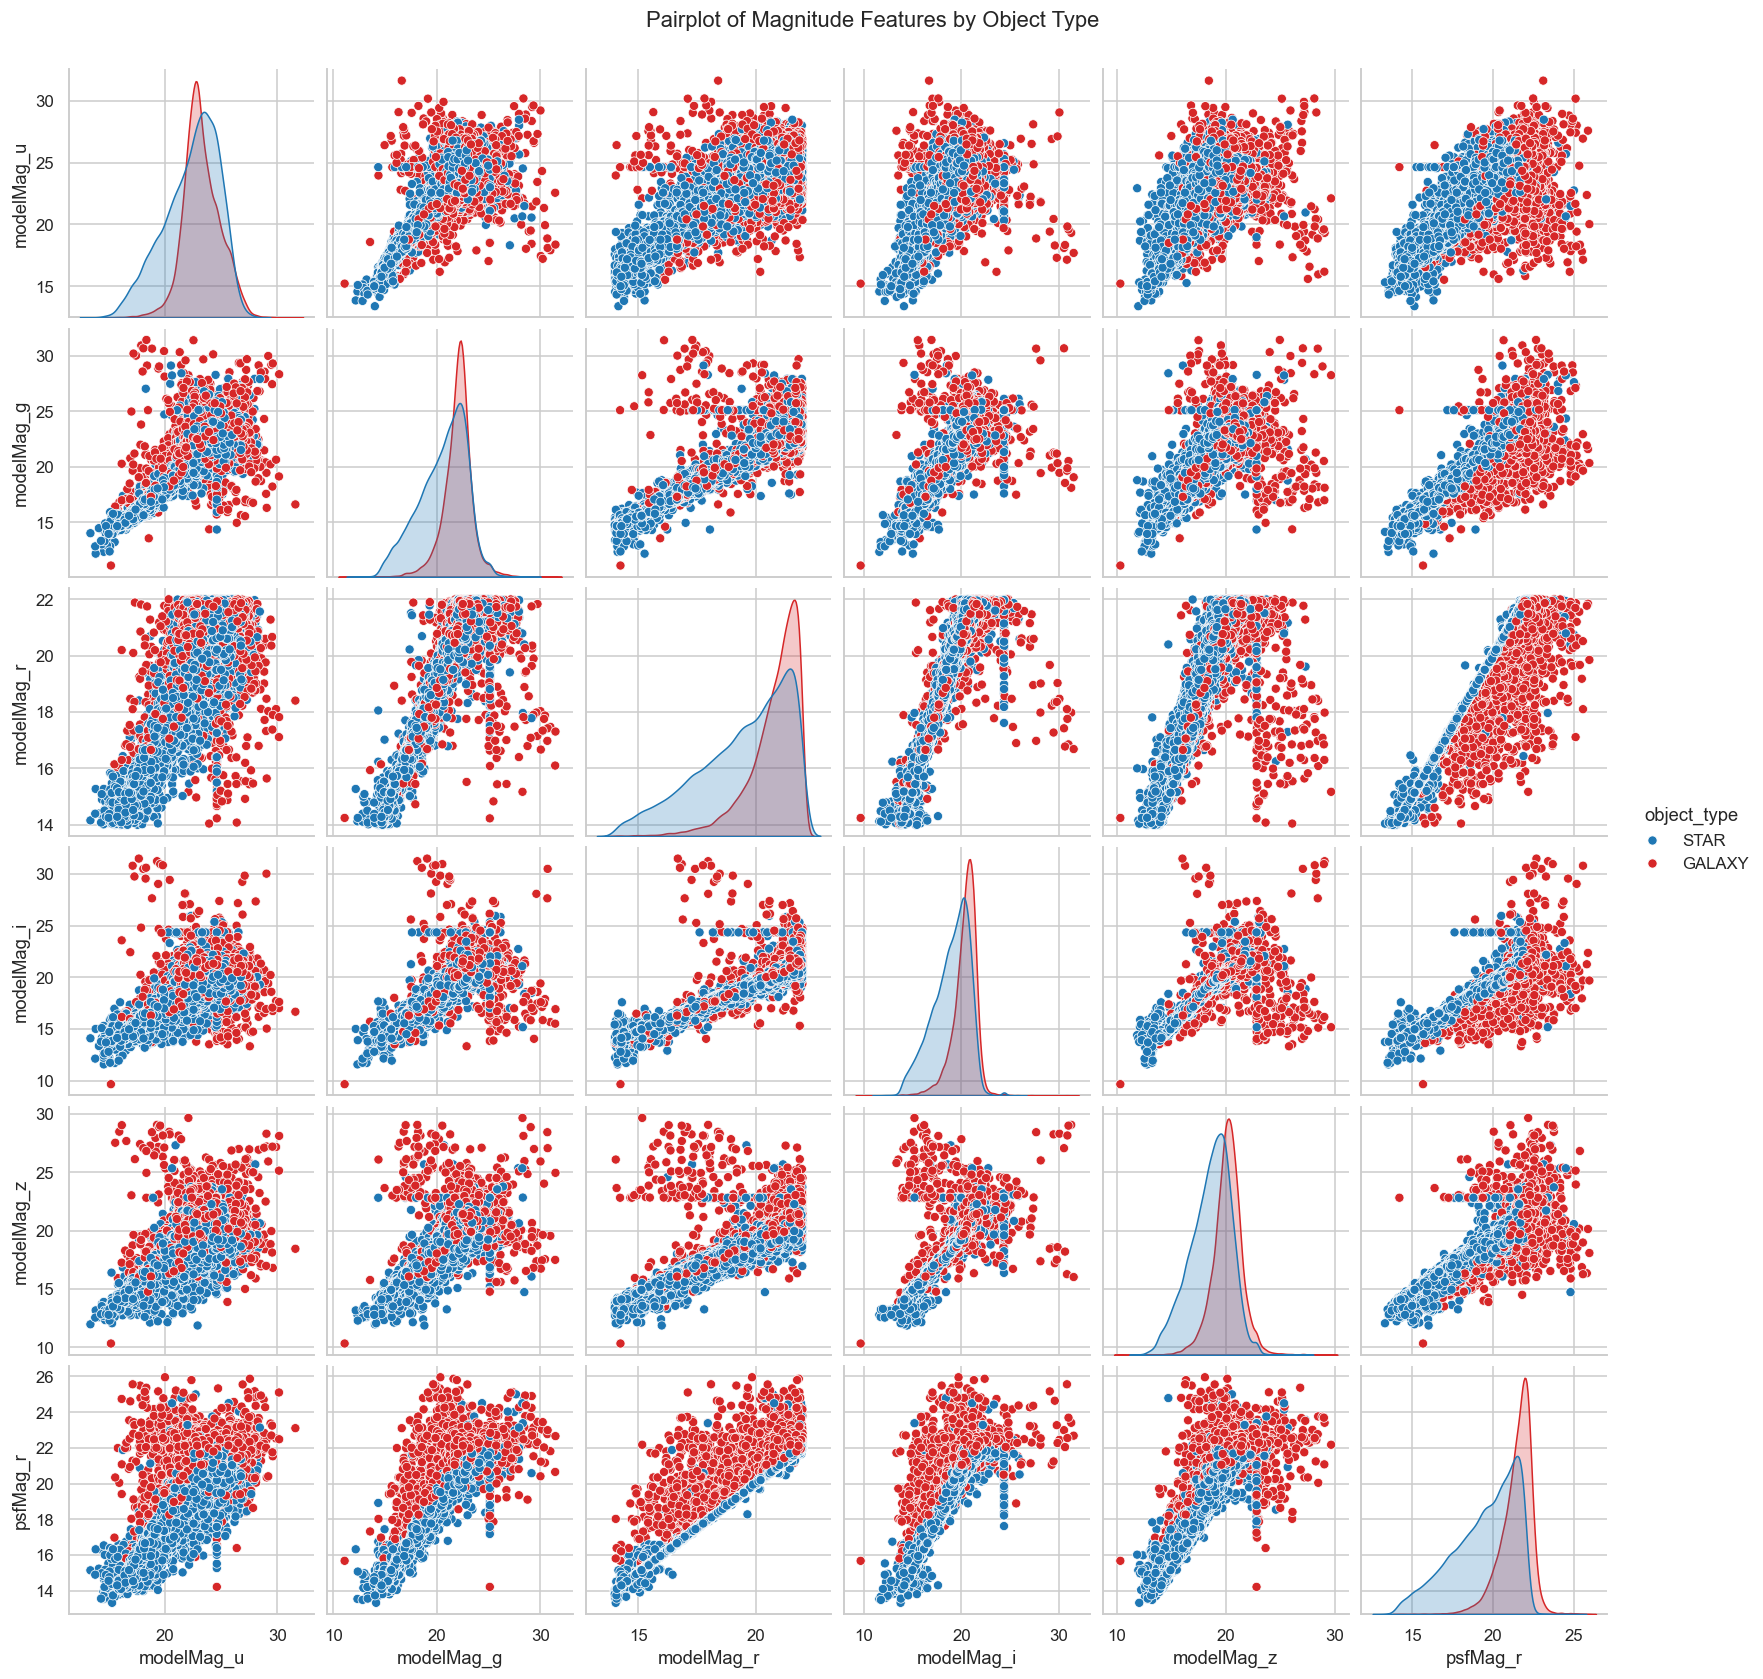

In [49]:
sns.pairplot(sdss, vars=mag_features, hue='object_type', palette=PALETTE, diag_kind='kde')
plt.suptitle('Pairplot of Magnitude Features by Object Type', y=1.02)
plt.show()  


### 2.5 Multicollinearity Analysis (VIF)

VIF interpretation:

- VIF < 5: Acceptable
- VIF 5-10: Moderate concern
- VIF > 10: High multicollinearity

- modelMag_r showed hisg VIF score(29.04) so exclude it and rerun the VIF calculation, psfMag_r is also showing high VIF score(12.03) also exluded

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm

vif_features = ['ra', 'dec'] + ["modelMag_u", "modelMag_g", "modelMag_z", "modelMag_i"]
vif = sdss[vif_features].copy()
vif = sm.add_constant(vif)

vif_df = pd.DataFrame({
    'feature': vif.columns,
    'VIF': [variance_inflation_factor(vif.values, i) for i in range(vif.shape[1])]
})

print(vif_df.round(2))

      feature     VIF
0       const  141.44
1          ra    1.05
2         dec    1.05
3  modelMag_u    3.05
4  modelMag_g    6.16
5  modelMag_z    6.60
6  modelMag_i    9.04


In [51]:
sdss.drop(columns=["modelMag_r", "psfMag_r"], inplace=True) # resulting in high VIF scores, so we will drop these features from the dataset

## 3. Data Preparation

The `clean` flag marks observations that pass all SDSS quality checks. We filter to clean-only observations before modelling to ensure data integrity.

In [52]:
# Checking for cleanness of the observations
sdss["clean"].value_counts()

clean
0    30438
1    14561
Name: count, dtype: int64

In [53]:
sdss_clean = sdss[sdss["clean"] == 1].copy()
print(f"Number of clean observations: {len(sdss_clean)}")

Number of clean observations: 14561


In [54]:
sdss_clean

,ra,dec,object_type,modelMag_u,modelMag_g,modelMag_i,modelMag_z,clean
11,350.352114,-6.941394,STAR,17.68810,15.78191,14.87754,14.75586,1
12,350.366793,-6.942336,STAR,20.81630,17.98068,15.56021,15.03705,1
13,350.368221,-6.867726,STAR,18.13195,16.75691,16.03243,15.92677,1
14,350.388585,-6.844772,STAR,21.25107,19.27319,17.86060,17.60316,1
15,350.384690,-6.844984,STAR,23.19518,21.30087,20.40335,20.77666,1
...,...,...,...,...,...,...,...,...
44989,350.773854,-6.997217,GALAXY,22.80946,22.52746,21.83079,21.53044,1
44990,350.779429,-6.950723,GALAXY,26.46445,23.29479,20.51744,19.90931,1
44991,350.778822,-7.019553,STAR,22.64366,23.39873,20.98582,20.69444,1
44992,350.783349,-6.965301,GALAXY,23.61116,22.75241,20.92687,21.06646,1


## 4. Modelling

Six classifiers are trained and tuned with `GridSearchCV` using 5-fold stratified cross-validation, scoring on **macro F1**. The target is binary: STAR = 0, GALAXY = 1.

In [55]:
sdss_clean["object_type"] = (sdss_clean["object_type"] == "GALAXY").astype(int)
y = sdss_clean["object_type"]

In [56]:
clean_counts = y.value_counts()
clean_percentages = clean_counts / len(sdss_clean) * 100
print("Clean Object Type Counts:")
print(clean_counts)
print("\nClean Object Type Percentages:")
print(clean_percentages)

Clean Object Type Counts:
object_type
0    9340
1    5221
Name: count, dtype: int64

Clean Object Type Percentages:
object_type
0    64.143946
1    35.856054
Name: count, dtype: float64


In [57]:
#train_test_split
X = sdss_clean.drop(columns=["object_type", "clean"], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [58]:
#cross validation
CV = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

### 4.1 Logistic Regression

In [59]:
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

grid_logreg = GridSearchCV(estimator=pipeline_logreg, param_grid={
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ["saga"],
    'classifier__max_iter': [200, 500],
    'classifier__penalty': ["elasticnet"],
    'classifier__l1_ratio': [0.5],
}, cv=CV, scoring='f1_macro', n_jobs=-1, verbose=2, refit=True)

grid_logreg.fit(X_train, y_train)
best_model = grid_logreg.best_estimator_
y_pred_logreg = best_model.predict(X_test)
print(classification_report(y_test, y_pred_logreg))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      1869
           1       0.69      0.63      0.66      1044

    accuracy                           0.77      2913
   macro avg       0.75      0.74      0.74      2913
weighted avg       0.76      0.77      0.76      2913



Accuracy: 0.765877102643323
Precision: 0.6889352818371608
Recall: 0.632183908045977
F1 Score: 0.6593406593406593


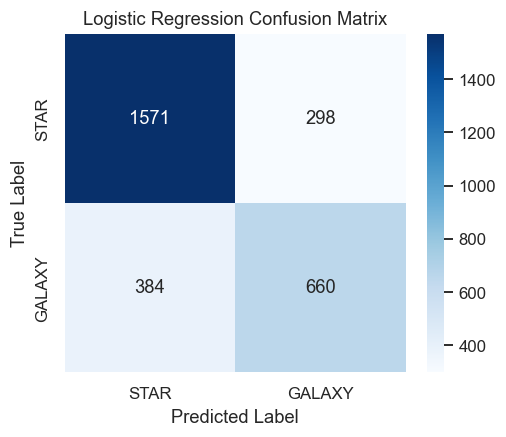

In [60]:
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:", recall_score(y_test, y_pred_logreg))
print("F1 Score:", f1_score(y_test, y_pred_logreg))

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap="Blues",
            xticklabels=['STAR', 'GALAXY'], yticklabels=['STAR', 'GALAXY'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 4.2 Random Forest

In [61]:
pipeline_rf = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

grid_rf = GridSearchCV(estimator = pipeline_rf, param_grid={
    'classifier__n_estimators': [100,200],
    'classifier__max_depth':[None, 10, 20],
    'classifier__min_samples_split':[2, 5, 10],
    'classifier__min_samples_leaf':[1, 2, 4]
    #'classifier__bootstrap': [True, False]
}, cv=CV, scoring="f1_macro", n_jobs=-1, verbose=1, refit=True)

grid_fit_rf = grid_rf.fit(X_train, y_train)
print("Best Random Forest Parameters:", grid_fit_rf.best_params_)
best_rf = grid_fit_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Random Forest Parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      1869
           1       0.78      0.76      0.77      1044

    accuracy                           0.84      2913
   macro avg       0.82      0.82      0.82      2913
weighted avg       0.83      0.84      0.83      2913



Accuracy: 0.835221421215242
Precision: 0.775390625
Recall: 0.7605363984674329
F1 Score: 0.7678916827852998


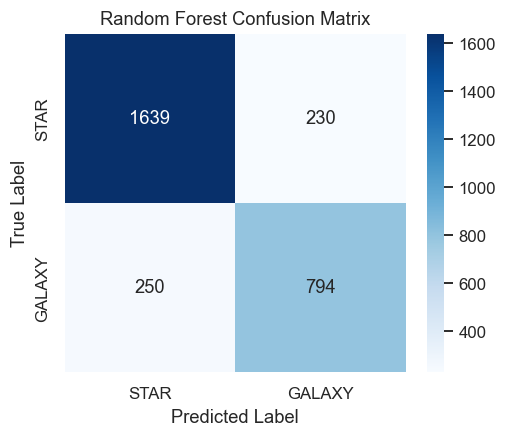

In [62]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Blues",
            xticklabels=['STAR', 'GALAXY'], yticklabels=['STAR', 'GALAXY'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 4.3 K-Nearest Neighbors (KNN)

In [65]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

grid_knn = GridSearchCV(estimator=pipeline_knn, param_grid={
    'classifier__n_neighbors':[3, 5, 7, 9, 11, 13 ,15, 17, 19],
    'classifier__weights' : ['uniform', 'distance'],
    'classifier__metric' : ['euclidean', 'manhattan', 'minkowski'],
    'classifier__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}, cv=CV, scoring='f1_macro', n_jobs=-1, verbose=2, refit=True)

grid_knn.fit(X_train, y_train)
print("Best Hyperparameters for KNN:", grid_knn.best_params_)
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)
print(classification_report(y_test, y_pred_knn))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Hyperparameters for KNN: {'classifier__algorithm': 'auto', 'classifier__metric': 'euclidean', 'classifier__n_neighbors': 17, 'classifier__weights': 'distance'}
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1869
           1       0.78      0.75      0.76      1044

    accuracy                           0.83      2913
   macro avg       0.82      0.82      0.82      2913
weighted avg       0.83      0.83      0.83      2913



Accuracy: 0.8341915550978373
Precision: 0.777998017839445
Recall: 0.7519157088122606
F1 Score: 0.7647345348270823


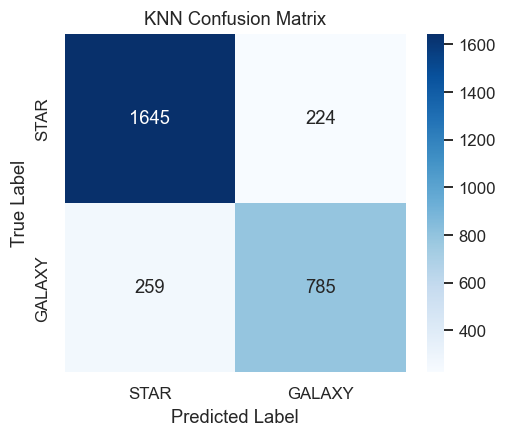

In [66]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=['STAR', 'GALAXY'], yticklabels=['STAR', 'GALAXY'])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 4.4 XGBoost

In [67]:
pipeline_xgb = Pipeline([
   ('classifier', XGBClassifier(random_state=42)) 
])

grid_xgb = GridSearchCV(estimator=pipeline_xgb, param_grid={
    'classifier__n_estimators':[100,200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__gamma': [0, 0.1, 0.2]
}, cv=CV, scoring='f1_macro', n_jobs=-1, verbose=2, refit=True)

grid_xgb.fit(X_train, y_train)
print("Best Hyperparameters for XGBoost:", grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Hyperparameters for XGBoost: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': None, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      1869
           1       0.78      0.76      0.77      1044

    accuracy                           0.84      2913
   macro avg       0.82      0.82      0.82      2913
weighted avg       0.84      0.84      0.84      2913



Accuracy: 0.8379677308616547
Precision: 0.7798434442270059
Recall: 0.7634099616858238
F1 Score: 0.771539206195547


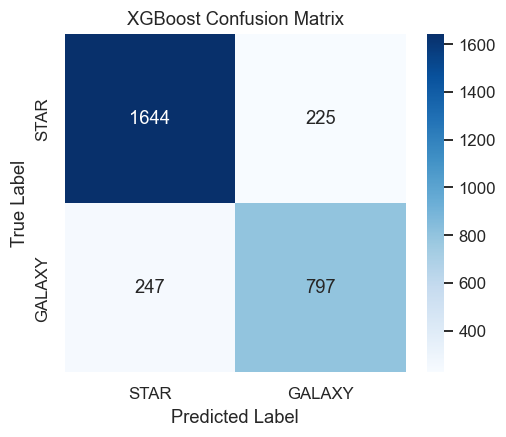

In [68]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap="Blues",
            xticklabels=['STAR', 'GALAXY'], yticklabels=['STAR', 'GALAXY'])
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 4.5 CatBoost

In [69]:
pipeline_cat = Pipeline([
    ('classifier', CatBoostClassifier(random_state=42))
])

grid_cat = GridSearchCV(estimator=pipeline_cat, param_grid={
    'classifier__iterations': [100, 200],
    'classifier__depth': [6, 10],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__l2_leaf_reg': [1, 3, 5],
    'classifier__border_count': [32, 64, 128]
}, cv=CV, scoring='f1_macro', n_jobs=-1, verbose=2, refit=True)

grid_cat.fit(X_train, y_train)
print("Best Hyperparameters for CatBoost:", grid_cat.best_params_)
best_cat = grid_cat.best_estimator_
y_pred_cat = best_cat.predict(X_test)
print(classification_report(y_test, y_pred_cat))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
0:	learn: 0.6430670	total: 9.07ms	remaining: 1.8s
1:	learn: 0.6041267	total: 14.3ms	remaining: 1.41s
2:	learn: 0.5728691	total: 20.6ms	remaining: 1.35s
3:	learn: 0.5477480	total: 25.5ms	remaining: 1.25s
4:	learn: 0.5276179	total: 29.9ms	remaining: 1.16s
5:	learn: 0.5115580	total: 34.6ms	remaining: 1.12s
6:	learn: 0.4977513	total: 39.2ms	remaining: 1.08s
7:	learn: 0.4867268	total: 44.2ms	remaining: 1.06s
8:	learn: 0.4783472	total: 49.8ms	remaining: 1.06s
9:	learn: 0.4700868	total: 54ms	remaining: 1.03s
10:	learn: 0.4641815	total: 58.7ms	remaining: 1.01s
11:	learn: 0.4592184	total: 63.2ms	remaining: 990ms
12:	learn: 0.4531432	total: 67.9ms	remaining: 976ms
13:	learn: 0.4493572	total: 72.7ms	remaining: 966ms
14:	learn: 0.4450816	total: 77.8ms	remaining: 959ms
15:	learn: 0.4412433	total: 82.8ms	remaining: 952ms
16:	learn: 0.4385086	total: 87.8ms	remaining: 945ms
17:	learn: 0.4361127	total: 92.5ms	remaining: 935ms
18:	learn: 0.43

Accuracy: 0.8403707518022657
Precision: 0.7780979827089337
Recall: 0.7758620689655172
F1 Score: 0.7769784172661871


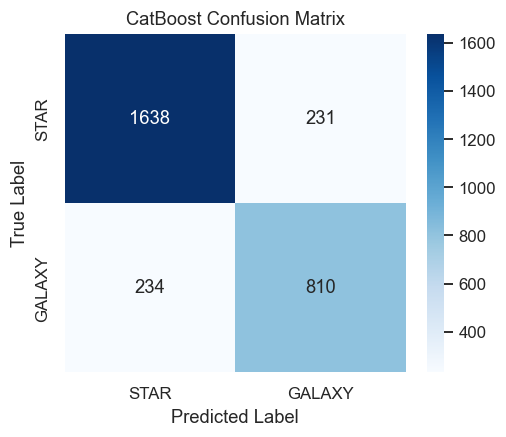

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall:", recall_score(y_test, y_pred_cat))
print("F1 Score:", f1_score(y_test, y_pred_cat))

cm_cat = confusion_matrix(y_test, y_pred_cat)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap="Blues",
            xticklabels=['STAR', 'GALAXY'], yticklabels=['STAR', 'GALAXY'])
plt.title("CatBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 5. Model Comparison

In [73]:

# Consolidate all model results into one dataframe
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN', 'XGBoost', 'CatBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_cat)
    ],
    'Precision': [
        precision_score(y_test, y_pred_logreg),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_cat)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logreg),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_cat)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_logreg),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_cat)
    ]
})

print("Model Comparison Results:")
print(results)

# Optional: Sort by F1 Score to see best performing model
print("\nModels Ranked by F1 Score:")
print(results.sort_values('F1 Score', ascending=False))

Model Comparison Results:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.765877   0.688935  0.632184  0.659341
1        Random Forest  0.835221   0.775391  0.760536  0.767892
2                  KNN  0.834192   0.777998  0.751916  0.764735
3              XGBoost  0.837968   0.779843  0.763410  0.771539
4             CatBoost  0.840371   0.778098  0.775862  0.776978

Models Ranked by F1 Score:
                 Model  Accuracy  Precision    Recall  F1 Score
4             CatBoost  0.840371   0.778098  0.775862  0.776978
3              XGBoost  0.837968   0.779843  0.763410  0.771539
1        Random Forest  0.835221   0.775391  0.760536  0.767892
2                  KNN  0.834192   0.777998  0.751916  0.764735
0  Logistic Regression  0.765877   0.688935  0.632184  0.659341


## 6. Conclusion

### Results Summary

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|:--------:|:---------:|:------:|:--------:|
| Logistic Regression | 0.766 | 0.689 | 0.632 | 0.659 |
| Random Forest | 0.835 | 0.775 | 0.761 | 0.768 |
| KNN | 0.834 | 0.778 | 0.752 | 0.765 |
| XGBoost | 0.838 | 0.780 | 0.763 | 0.772 |
| **CatBoost** | **0.840** | **0.778** | **0.776** | **0.777** |

### Key Findings

- **CatBoost** achieved the best overall performance with **84.0% accuracy** and **0.777 macro F1**, closely followed by XGBoost (0.772) and Random Forest (0.768).
- **Tree-based ensemble methods** consistently outperformed linear and distance-based models, indicating non-linear decision boundaries between stellar classes.
- **`modelMag_r` and `psfMag_r`** were dropped due to high VIF scores (29.04 and 12.03 respectively) indicating severe multicollinearity with the remaining magnitude bands.
- Filtering to **clean observations only** (14,561 / 45,000) improved data quality at the cost of ~68% of the dataset.
- Due to class imbalance on target feature we mostly used tree based models other than the bas model which is Logistic Regression.

### Possible Next Actions

- Engineer **colour index features** (u−g, g−r, r−i, i−z) — standard photometric separators in stellar classification.
- Investigate whether training on the full dataset with `clean` as an additional feature improves generalization.
- Fit a model for non-clean samples to see seperation helps generalization.
- Identify SMOTE is needed and class imbalance severity.
- Perform **error analysis** on misclassified objects, particularly galaxies misclassified as stars (false negatives).
- Build a navie CNN for image datas.